Träningsiterationer (x10000 spel)


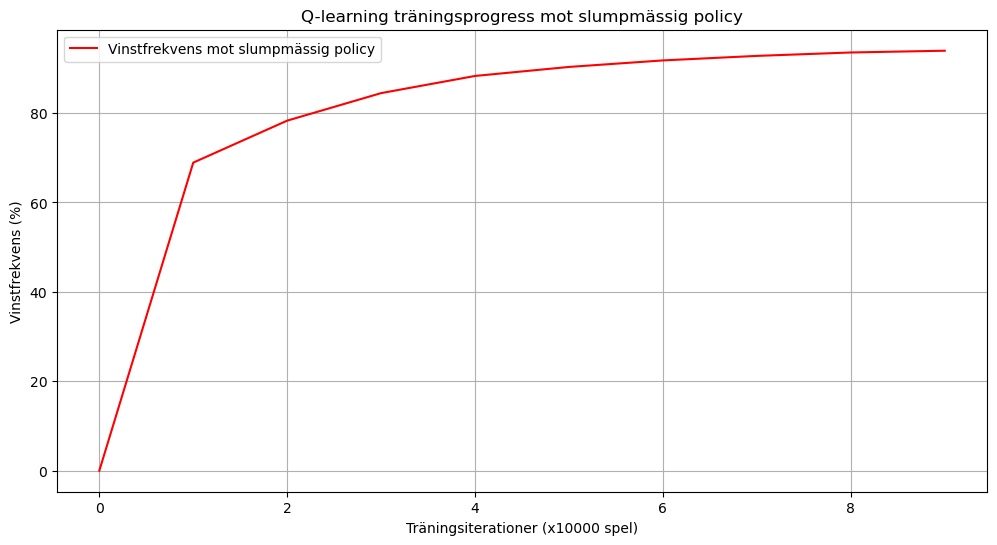

Resultat mot slumpmässig policy:
Vinster: 4738
Oavgjorda: 99
Förluster: 181


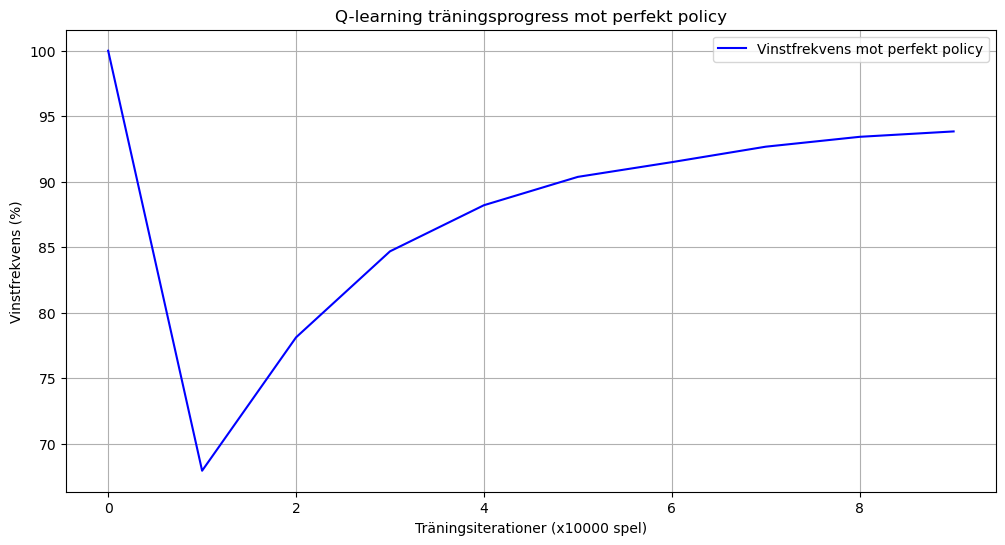

Resultat mot perfekt policy:
Vinster: 4697
Oavgjorda: 96
Förluster: 189


In [5]:
import numpy as np
import pickle
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Ladda den perfekta policyn (för utvärdering och imitation learning)
perfect_policy_path = "perfectPolicy.p"
with open(perfect_policy_path, "rb") as f:
    perfectPolicy = pickle.load(f)

# Definierar en slumpmässig policy som väljer ett drag jämnt fördelat bland de tomma platserna på brädet
def random_policy(board):
    empty = getEmpty(board)
    return np.array([1/len(empty) if i in empty else 0 for i in range(9)]) if empty else np.zeros(9)

# Utvärderar brädet och returnerar vinnaren (1 eller 2), 0 vid oavgjort, eller -1 om spelet inte är över
def stateOfBoard(board):
    for i in range(3):
        if board[3 * i] == board[3 * i + 1] == board[3 * i + 2] != 0:
            return board[3 * i]
        if board[i] == board[i + 3] == board[i + 6] != 0:
            return board[i]
    if board[0] == board[4] == board[8] != 0 or board[2] == board[4] == board[6] != 0:
        return board[4]
    if 0 not in board:
        return 0
    return -1

# Returnerar en lista över de tomma positionerna på brädet
def getEmpty(board):
    return [i for i, cell in enumerate(board) if cell == 0]

# Utför ett drag genom att uppdatera brädet med spelarens drag på den valda positionen
def makeMove(board, location, player):
    board = list(board)
    board[location] = player
    return tuple(board)

# Väljer en handling baserat på epsilon-gredd strategi (slumpmässigt val eller bästa Q-värde)
def choose_action(board, epsilon):
    empty_cells = getEmpty(board)
    if not empty_cells:
        return None
    if np.random.rand() < epsilon:
        return random.choice(empty_cells)  # Utforskning
    q_values = Q[board]
    max_q = max(q_values[i] for i in empty_cells)
    best_moves = [i for i in empty_cells if q_values[i] == max_q]
    return random.choice(best_moves)  # Exploatering

# Uppdaterar Q-tabellen med hjälp av Bellman-ekvationen baserat på upplevd belöning
def update_q_table(states, actions, reward):
    for i in range(len(actions) - 1):
        state, action = states[i], actions[i]
        next_state = states[i + 1]
        if next_state not in Q:
            Q[next_state] = np.zeros(9)
        max_q_next = max(Q[next_state])
        Q[state][action] += alpha * (reward + gamma * max_q_next - Q[state][action])

# Tränar en Q-learning policy genom att spela mot en slumpmässig och en perfekt policy
def train_q_learning(episodes=10000):
    win_rates_random, win_rates_perfect = [], []
    global epsilon
    results_random = {"win": 0, "draw": 0, "loss": 0}
    results_perfect = {"win": 0, "draw": 0, "loss": 0}
    x_label = f"Träningsiterationer (x{episodes} spel)"
    print(f"{x_label}")
    for episode in range(episodes):
        board = (0,) * 9
        player = 1
        states, actions = [], []
        opponent = random_policy if random.random() < 0.5 else perfectPolicy
        while stateOfBoard(board) == -1:
            action = choose_action(board, epsilon)
            if action is None:
                break
            states.append(board)
            actions.append(action)
            board = makeMove(board, action, player)
            player = 3 - player
        
        outcome = stateOfBoard(board)
        reward = 1 if outcome == 1 else -1 if outcome == 2 else 0
        update_q_table(states, actions, reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        if opponent == random_policy:
            results_random["win" if outcome == 1 else "draw" if outcome == 0 else "loss"] += 1
        else:
            results_perfect["win" if outcome == 1 else "draw" if outcome == 0 else "loss"] += 1
        
        if episode % 1000 == 0:
            total_random = sum(results_random.values()) or 1  # Undvik division med noll
            total_perfect = sum(results_perfect.values()) or 1  # Undvik division med noll
            win_rates_random.append(results_random["win"] / total_random * 100)
            win_rates_perfect.append(results_perfect["win"] / total_perfect * 100)
    
    # Graf för slumpmässig policy
    plt.figure(figsize=(12, 6))
    plt.plot(win_rates_random, color='red', label="Vinstfrekvens mot slumpmässig policy")
    plt.xlabel(x_label)
    plt.ylabel("Vinstfrekvens (%)")
    plt.title("Q-learning träningsprogress mot slumpmässig policy")
    plt.legend()
    plt.grid()
    plt.show()
    print("Resultat mot slumpmässig policy:")
    print(f"Vinster: {results_random['win']}\nOavgjorda: {results_random['draw']}\nFörluster: {results_random['loss']}")
    
    # Graf för perfekt policy
    plt.figure(figsize=(12, 6))
    plt.plot(win_rates_perfect, color='blue', label="Vinstfrekvens mot perfekt policy")
    plt.xlabel(x_label)
    plt.ylabel("Vinstfrekvens (%)")
    plt.title("Q-learning träningsprogress mot perfekt policy")
    plt.legend()
    plt.grid()
    plt.show()
    print("Resultat mot perfekt policy:")
    print(f"Vinster: {results_perfect['win']}\nOavgjorda: {results_perfect['draw']}\nFörluster: {results_perfect['loss']}")

# Q-learning parametrar
alpha = 0.5  # Inlärningshastighet
gamma = 0.99  # Diskonteringsfaktor
epsilon = 1.0  # Initialt utforskningsvärde
epsilon_decay = 0.999  # Långsammare minskning
epsilon_min = 0.05  # Minimalt epsilon

default_q_value = 0.0
Q = defaultdict(lambda: np.zeros(9))

# Starta träningen
train_q_learning()

# Spara Q-tabellen till en fil
with open("q_table.p", "wb") as f:
    pickle.dump(dict(Q), f)

